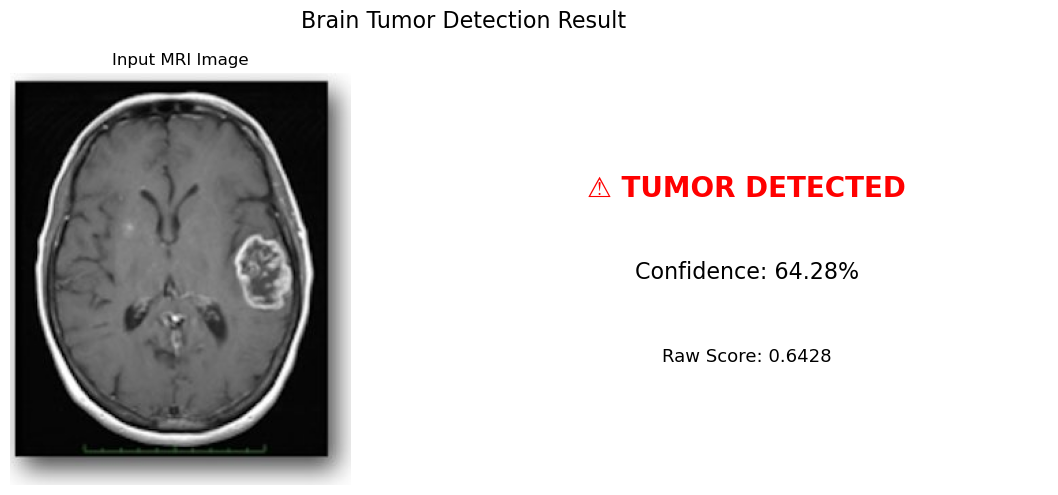

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import cv2
import matplotlib.pyplot as plt

model = keras.models.load_model('best_brain_tumor_model.h5')

def predict_tumor(image_path, model, img_size=(224, 224)):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, img_size)
    img_array = np.array(img) / 255.0 
    img_array = np.expand_dims(img_array, axis=0) 
    prediction = model.predict(img_array, verbose=0)[0][0]
    if prediction > 0.5:
        class_name = 'Tumor Detected'
        confidence = prediction * 100
    else:
        class_name = 'No Tumor Detected'
        confidence = (1 - prediction) * 100
    return prediction, class_name, confidence

def visualize_prediction(image_path, model, img_size=(224, 224)):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    prediction, class_name, confidence = predict_tumor(image_path, model, img_size)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.imshow(img_rgb)
    ax1.set_title('Input MRI Image')
    ax1.axis('off')
    ax2.axis('off')
    if prediction > 0.5:
        color = 'red'
        result_text = f"⚠️ TUMOR DETECTED"
    else:
        color = 'green'
        result_text = f"✅ NO TUMOR DETECTED"
    ax2.text(0.5, 0.7, result_text, fontsize=20, fontweight='bold', color=color,horizontalalignment='center', transform=ax2.transAxes)
    ax2.text(0.5, 0.5, f"Confidence: {confidence:.2f}%", fontsize=16, horizontalalignment='center', transform=ax2.transAxes)
    ax2.text(0.5, 0.3, f"Raw Score: {prediction:.4f}", fontsize=13, horizontalalignment='center', transform=ax2.transAxes)
    
    plt.suptitle('Brain Tumor Detection Result', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    return prediction, class_name, confidence

image_path = "image1.jpg"  
prediction, class_name, confidence = visualize_prediction(image_path, model)